In [6]:
import sys
# # 1. This installs the specific GPU version into your active environment
# !{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [2]:
import os
import sys

# This adds the folder from your warning to the active Path
conda_path = r'C:\Users\ivano\miniconda3\Scripts'
if conda_path not in os.environ["PATH"]:
    os.environ["PATH"] += os.path.sep + conda_path

# Now try to import
try:
    print(f"PyTorch Version: {torch.__version__}")
    print(f"Is CUDA available? {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU detected: {torch.cuda.get_device_name(0)}")
except NameError:
    print("Torch is still not installed correctly.")

Torch is still not installed correctly.


In [3]:
# pip install matplotlib

Target Hardware: cuda
----------------------------------------
STEP: A: Initial (CPU) | DEVICE: cpu | ADDR: 0x2f6b4010080
STEP: B: Transfer to GPU | DEVICE: cuda:0 | ADDR: 0x1314a00000
STEP: C: Return to CPU | DEVICE: cpu | ADDR: 0x2f6b40100c0


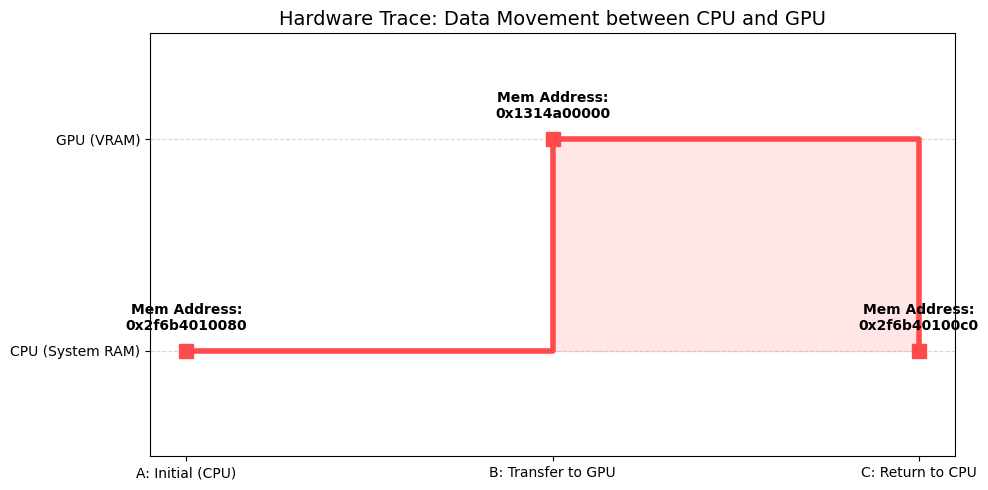

In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the Trace Logger
data_trace = []

def log_data_location(tensor, step_name):
    """Captures the hardware device and the specific memory pointer."""
    device_type = str(tensor.device)
    # .data_ptr() gives the actual location in hardware memory
    address = tensor.data_ptr() 
    data_trace.append({
        'step': step_name, 
        'device': device_type, 
        'address': hex(address)
    })
    print(f"STEP: {step_name} | DEVICE: {device_type} | ADDR: {hex(address)}")

# 2. Hardware Detection
# If this says 'cpu', your computer's GPU drivers are not connected to PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Target Hardware: {device}\n" + "-"*40)

# --- DATA MOVEMENT PHASE ---

# STEP A: Create on CPU
x = torch.tensor([10.0, 20.0, 30.0], dtype=torch.float32)
log_data_location(x, "A: Initial (CPU)")

# STEP B: Move to GPU (The physical transfer across PCIe bus)
if torch.cuda.is_available():
    x = x.to(device)
    log_data_location(x, "B: Transfer to GPU")
else:
    print("WARNING: CUDA not found. Step B will stay on CPU.")
    log_data_location(x, "B: (Stayed on CPU)")

# STEP C: Return to CPU (Pulling data back to System RAM)
x = x.cpu()
log_data_location(x, "C: Return to CPU")

# --- PLOTTING THE TRACE ---

steps = [d['step'] for d in data_trace]
# Map: CPU = 0, GPU = 1
y_vals = [1 if 'cuda' in d['device'] else 0 for d in data_trace]

plt.figure(figsize=(10, 5))
# Use a 'step' plot to show the sudden jumps between hardware
plt.step(steps, y_vals, where='post', marker='s', color='#ff4b4b', linewidth=4, markersize=10)
plt.fill_between(steps, y_vals, step="post", alpha=0.1, color='red')

# Formatting the Chart
plt.yticks([0, 1], ['CPU (System RAM)', 'GPU (VRAM)'])
plt.ylim(-0.5, 1.5)
plt.title("Hardware Trace: Data Movement between CPU and GPU", fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Annotate memory addresses on the plot
for i, d in enumerate(data_trace):
    plt.annotate(f"Mem Address:\n{d['address']}", (steps[i], y_vals[i]), 
                 textcoords="offset points", xytext=(0, 15), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
import torch

gpu_count = torch.cuda.device_count()
print(f"Total GPUs detected: {gpu_count}")

for i in range(gpu_count):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

Total GPUs detected: 1
GPU 0: NVIDIA GeForce RTX 4090
